# 03 — HuggingFace Optimum (ORT backend)

Loads PP-LCNet_x1_0_doc_ori via `ORTModelForImageClassification` (Optimum ORT wrapper).
Uses the same `model.onnx` as notebook 02 — measures wrapper overhead vs raw ORT.

Model dir `models/optimum/` contains:
- `model.onnx`  — copied from `models/model.onnx`
- `config.json` — HuggingFace-style label config (required by Optimum)

In [1]:
import sys
sys.path.insert(0, '..')

import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from optimum.onnxruntime import ORTModelForImageClassification

from src.preprocess import load_and_preprocess

OPTIMUM_DIR = Path('../models/optimum')
DATASET_CSV = Path('../data/dataset.csv')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Optimum model dir : {OPTIMUM_DIR}')
print(f'Files             : {[f.name for f in OPTIMUM_DIR.iterdir()]}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


Optimum model dir : ../models/optimum
Files             : ['config.json', 'model.onnx']


In [2]:
model = ORTModelForImageClassification.from_pretrained(
    str(OPTIMUM_DIR),
    local_files_only=True,
)
print(f'Model loaded via Optimum ORT')
print(f'Providers : {model.model.get_providers()}')

Model loaded via Optimum ORT
Providers : ['CPUExecutionProvider']


In [3]:
def predict(image_path: str) -> tuple[int, float]:
    tensor_np = load_and_preprocess(image_path)                  # (1,3,224,224) float32
    pixel_values = torch.from_numpy(tensor_np)
    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits.detach().numpy()
    pred_label = int(np.argmax(logits, axis=1)[0])
    confidence = float(np.max(logits))
    return pred_label, confidence

df = pd.read_csv(DATASET_CSV)

# Warm-up
_ = predict(df.iloc[0]['image_path'])
print('Warmed up.')

predictions, confidences, latencies = [], [], []

for row in tqdm(df.itertuples(), total=len(df), desc='Optimum ORT inference'):
    t0 = time.perf_counter()
    pred, conf = predict(row.image_path)
    latencies.append((time.perf_counter() - t0) * 1000)
    predictions.append(pred)
    confidences.append(conf)

df['optimum_pred']       = predictions
df['optimum_conf']       = confidences
df['optimum_latency_ms'] = latencies
df.to_csv(RESULTS_DIR / 'optimum_results.csv', index=False)
print('Saved results/optimum_results.csv')

Warmed up.


Optimum ORT inference:   0%|          | 0/552 [00:00<?, ?it/s]

Optimum ORT inference:   1%|          | 4/552 [00:00<00:17, 31.75it/s]

Optimum ORT inference:   1%|▏         | 8/552 [00:00<00:16, 33.63it/s]

Optimum ORT inference:   2%|▏         | 12/552 [00:00<00:16, 32.28it/s]

...

Optimum ORT inference:  98%|█████████▊| 542/552 [00:16<00:00, 32.04it/s]

Optimum ORT inference:  99%|█████████▉| 546/552 [00:17<00:00, 31.58it/s]

Optimum ORT inference: 100%|█████████▉| 550/552 [00:17<00:00, 30.93it/s]

Optimum ORT inference: 100%|██████████| 552/552 [00:17<00:00, 31.86it/s]

Saved results/optimum_results.csv


In [4]:
import torch

def predict(image_path: str) -> tuple[int, float]:
    # load_and_preprocess returns (1, 3, 224, 224) numpy float32
    tensor_np = load_and_preprocess(image_path)
    pixel_values = torch.from_numpy(tensor_np)  # Optimum expects torch tensor
    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits.detach().numpy()
    pred_label = int(np.argmax(logits, axis=1)[0])
    confidence = float(np.max(logits))
    return pred_label, confidence

df = pd.read_csv(DATASET_CSV)

predictions, confidences, latencies = [], [], []

for row in tqdm(df.itertuples(), total=len(df), desc='Optimum ORT inference'):
    t0 = time.perf_counter()
    pred, conf = predict(row.image_path)
    latencies.append((time.perf_counter() - t0) * 1000)
    predictions.append(pred)
    confidences.append(conf)

df['optimum_pred'] = predictions
df['optimum_conf'] = confidences
df['optimum_latency_ms'] = latencies
df.to_csv(RESULTS_DIR / 'optimum_results.csv', index=False)
print('Saved results/optimum_results.csv')

Optimum ORT inference:   0%|          | 0/552 [00:00<?, ?it/s]

Optimum ORT inference:   1%|          | 4/552 [00:00<00:16, 33.34it/s]

Optimum ORT inference:   1%|▏         | 8/552 [00:00<00:15, 34.22it/s]

Optimum ORT inference:   2%|▏         | 12/552 [00:00<00:16, 33.14it/s]

Optimum ORT inference:   3%|▎         | 16/552 [00:00<00:16, 33.08it/s]

...

Optimum ORT inference:  98%|█████████▊| 542/552 [00:16<00:00, 32.13it/s]

Optimum ORT inference:  99%|█████████▉| 546/552 [00:16<00:00, 31.63it/s]

Optimum ORT inference: 100%|█████████▉| 550/552 [00:17<00:00, 30.86it/s]

Optimum ORT inference: 100%|██████████| 552/552 [00:17<00:00, 32.26it/s]

Saved results/optimum_results.csv


Accuracy:         0.8913
Avg latency:      30.88 ms
Throughput:       32.4 img/s

              precision    recall  f1-score   support

        0deg       0.89      0.91      0.90       138
       90deg       0.90      0.90      0.90       138
      180deg       0.88      0.87      0.88       138
      270deg       0.90      0.89      0.89       138

    accuracy                           0.89       552
   macro avg       0.89      0.89      0.89       552
weighted avg       0.89      0.89      0.89       552



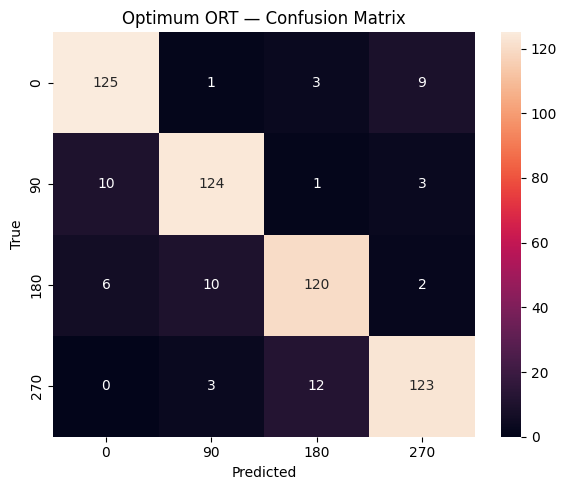

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = (df['optimum_pred'] == df['label']).mean()
avg_latency = df['optimum_latency_ms'].mean()
throughput = 1000 / avg_latency

print(f'Accuracy:         {accuracy:.4f}')
print(f'Avg latency:      {avg_latency:.2f} ms')
print(f'Throughput:       {throughput:.1f} img/s')
print()
print(classification_report(df['label'], df['optimum_pred'],
                             target_names=['0deg','90deg','180deg','270deg']))

cm = confusion_matrix(df['label'], df['optimum_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['0','90','180','270'],
            yticklabels=['0','90','180','270'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Optimum ORT — Confusion Matrix')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'optimum_confusion_matrix.png', dpi=150)
plt.show()